In [71]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sea
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split

In [19]:
#chargement avec le bon separateur
data = pd.read_csv('data/student-mat-before.csv', sep=';')

Valeurs manquantes par colonnes :
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Nombre de lignes en double : 0


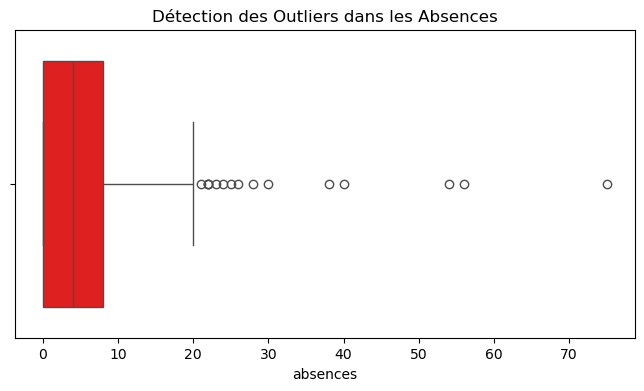

In [20]:
#1. verification des valeurs manquantes
print("Valeurs manquantes par colonnes :")
print(data.isnull().sum())

#2.Verification des doublons 
dubl = data.duplicated()
dubl_count = dubl.sum()
print(f"\nNombre de lignes en double : {dubl_count}")

#3.Analyse des Outliers
plt.figure(figsize=(8, 4))
sea.boxplot(x=data['absences'], color='red')
plt.title('Détection des Outliers dans les Absences')
plt.show()

In [21]:
#List des colonnes jugees inutiles (aucune valeur ajouter pour notre projet)
drop_cols = ['school', 'reason', 'address']
#Suppression des colonnes 
data_reduced = data.drop(columns=drop_cols)
print(f"Ancien nombre de colonnes : {data.shape[1]}")
print(f"Neouveau nombre de colonnes : {data_reduced.shape[1]}")

Ancien nombre de colonnes : 33
Neouveau nombre de colonnes : 30


In [60]:
#Encodage des variables categoriel 
#1.Detection des colonnes de deux choi ---> OrdinalEncoder
binary_cols = ['sex', 'famsize', 'Pstatus', 'schoolsup', 'famsup', 'paid',
               'activities', 'nursery', 'higher', 'internet', 'romantic']

#Application de {OrdinalEncoder}
ordinal_encod= OrdinalEncoder()
data_reduced[binary_cols] = ordinal_encod.fit_transform(data_reduced[binary_cols])

In [61]:
#2.Detection des variables nominiales (> 2 categ) ---> OneHotEncoder
nominal_cols = ['Mjob', 'Fjob', 'guardian']

#Application de {OneHotEncoder}
onehot_encod = OneHotEncoder(sparse_output=False, drop='first')
nominal_encod = onehot_encod.fit_transform(data_reduced[nominal_cols])

In [62]:
#Cree un dataframe avec les nouveaux noms 
nominla_datafarme= pd.DataFrame(nominal_encod,columns=onehot_encod.get_feature_names_out(nominal_cols),index=data_reduced.index)

print(nominla_datafarme.shape[1])

10


In [63]:
#Fusion avec la dataset principale et supp des colonnes text 
final_data = pd.concat([data_reduced.drop(columns=nominal_cols), nominla_datafarme], axis=1)
print(data_final.head())

   sex  age  famsize  Pstatus  Medu  Fedu  traveltime  studytime  failures  \
0  0.0   18      0.0      0.0     4     4           2          2         0   
1  0.0   17      0.0      1.0     1     1           1          2         0   
2  0.0   15      1.0      1.0     1     1           1          2         3   
3  0.0   15      0.0      1.0     4     2           1          3         0   
4  0.0   16      0.0      1.0     3     3           1          2         0   

   schoolsup  ...  Mjob_health  Mjob_other  Mjob_services  Mjob_teacher  \
0        0.0  ...          0.0         0.0            0.0           0.0   
1        1.0  ...          0.0         0.0            0.0           0.0   
2        0.0  ...          0.0         0.0            0.0           0.0   
3        1.0  ...          1.0         0.0            0.0           0.0   
4        1.0  ...          0.0         1.0            0.0           0.0   

   Fjob_health  Fjob_other  Fjob_services  Fjob_teacher  guardian_mother  \
0   

In [64]:
import os

final_data.to_csv('data/student-cleaned.csv', index=False)
print("Le fichier student-cleaned.csv enregistre avec succes !")

Le fichier student-cleaned.csv enregistre avec succes !


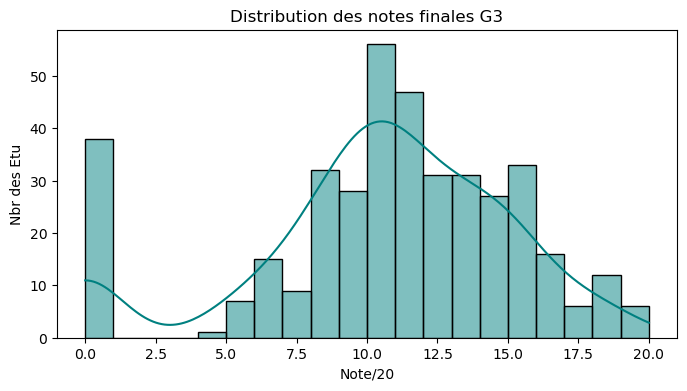

In [65]:
#la visulaisation des donnes
# 1. Histogramme de la variable cible G3
plt.figure(figsize=(8, 4))
sea.histplot(final_data['G3'], bins=20, kde=True, color='teal')
plt.title('Distribution des notes finales G3')
plt.xlabel('Note/20')
plt.ylabel('Nbr des Etu')
plt.show()

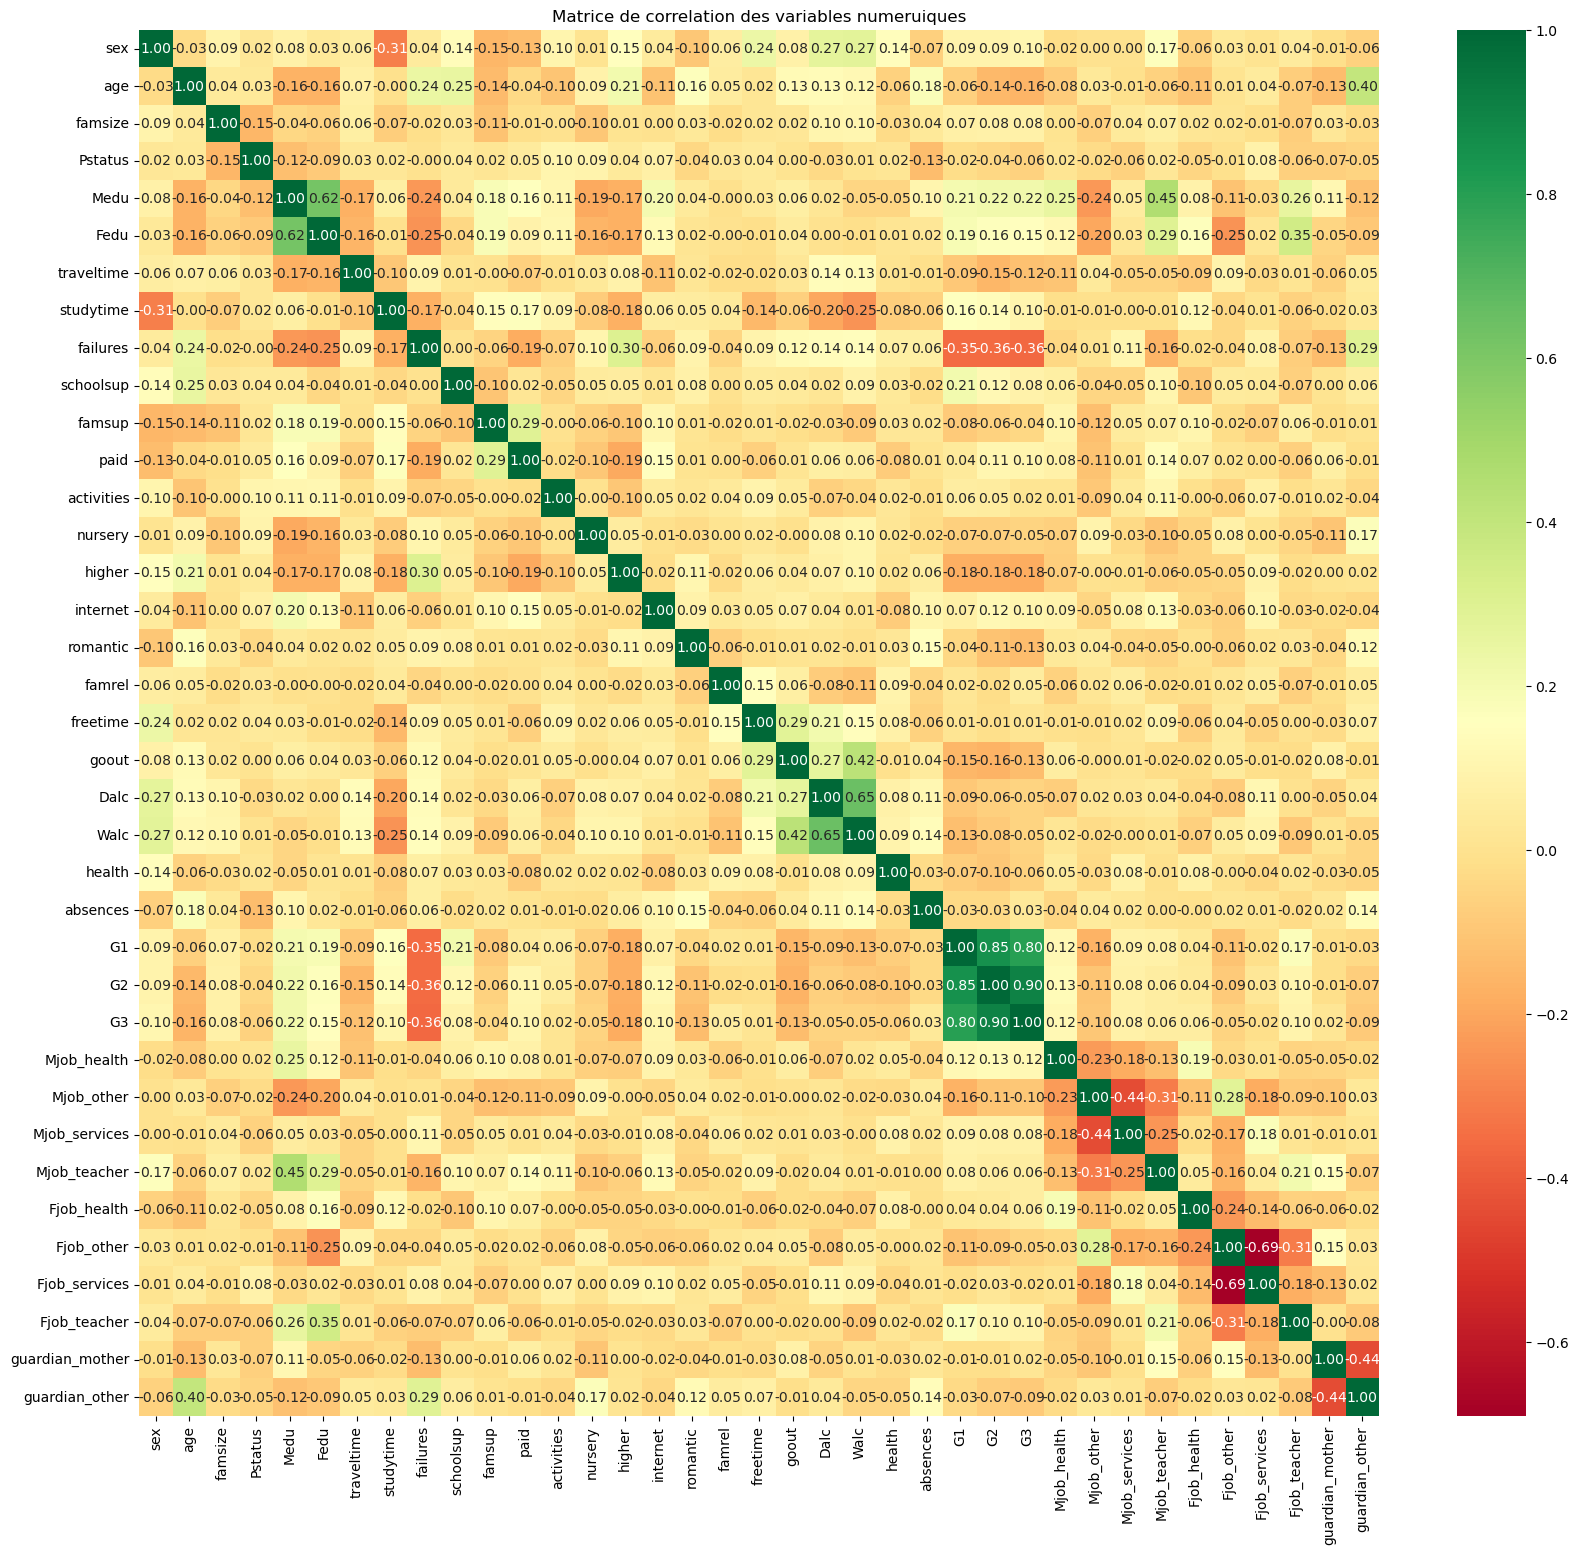

In [66]:
# 2. Matrice de correlation
#select only les colonnes numerique
num_cl_of_data = final_data.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(20, 18))
sea.heatmap(num_cl_of_data.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Matrice de correlation des variables numeruiques')
plt.show()

C:\Users\pc HD\AppData\Local\Temp\ipykernel_20604\2874701607.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sea.scatterplot(x=final_data['studytime'], y=final_data['G3'], palette='Set3')


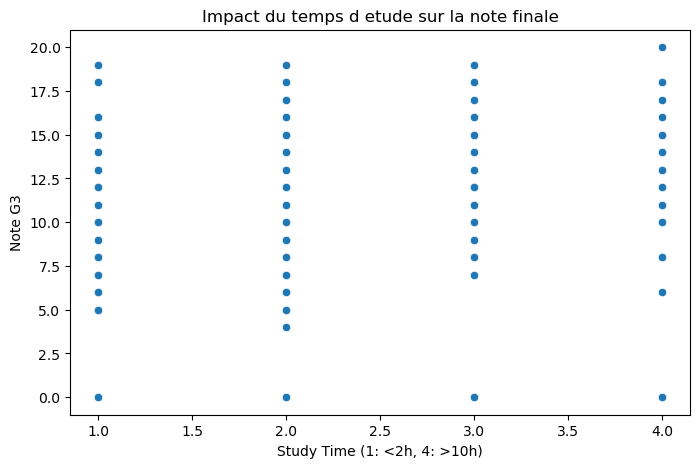

In [67]:
# 3. La relation entre StudyTime Vs G3
plt.figure(figsize=(8, 5))
sea.scatterplot(x=final_data['studytime'], y=final_data['G3'], palette='Set3')
plt.title('Impact du temps d etude sur la note finale')
plt.xlabel('Study Time (1: <2h, 4: >10h)')
plt.ylabel('Note G3')
plt.show()

C:\Users\pc HD\AppData\Local\Temp\ipykernel_20604\153754366.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sea.scatterplot(x='absences', y='G3', data=final_data, palette='Set6')


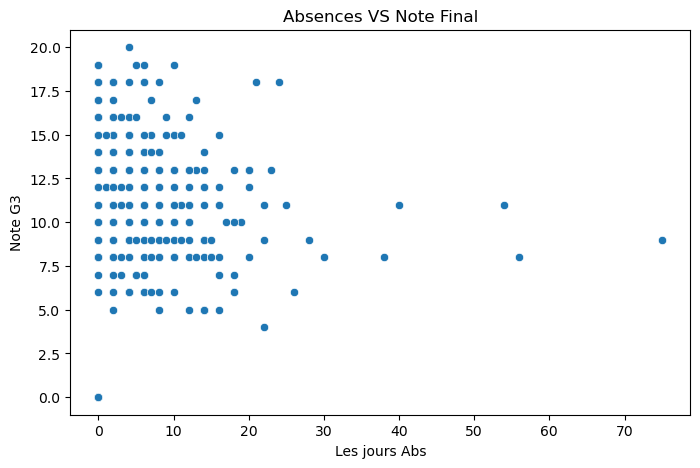

In [69]:
# 4.Relation entre Absences VS G3
plt.figure(figsize=(8, 5))
sea.scatterplot(x='absences', y='G3', data=final_data, palette='Set6')
plt.title('Absences VS Note Final')
plt.xlabel('Les jours Abs')
plt.ylabel('Note G3')
plt.show()

In [73]:
# Separation des donnees Features/Target
X = final_data.drop('G3', axis=1)
Y = final_data['G3']
#Split train/ test
X_train,X_test,Y_train,Y_test = train_test_split(X,Y, test_size=0.2,random_state=42)
#Afficher dimension
print("X_train: ",X_train.shape)
print("X_test: ",X_test.shape)
print("y_train: ",Y_train.shape)
print("y_test: ",Y_test.shape)

X_train:  (316, 36)
X_test:  (79, 36)
y_train:  (316,)
y_test:  (79,)


In [74]:
X_train.to_csv("data/X_train.csv", index=False)
X_test.to_csv("data/X_test.csv", index=False)

In [75]:
!git init

Initialized empty Git repository in C:/Users/pc HD/PFE-DATA/.git/


In [78]:
!git add .

In [79]:
!git commit -m "إضافة ملفات التحليل وتنظيف البيانات"

[master (root-commit) 4c8aee8] Ø¥Ø¶Ø§Ù�Ø© Ù…Ù„Ù�Ø§Øª Ø§Ù„ØªØ­Ù„ÙŠÙ„ ÙˆØªÙ†Ø¸ÙŠÙ� Ø§Ù„Ø¨ÙŠØ§Ù†Ø§Øª
 11 files changed, 3236 insertions(+)
 create mode 100644 .ipynb_checkpoints/Exploratory-Data-Analysis - EDA-checkpoint.ipynb
 create mode 100644 .ipynb_checkpoints/Nettoyage_des_donnees-checkpoint.ipynb
 create mode 100644 Exploratory-Data-Analysis - EDA.ipynb
 create mode 100644 Nettoyage_des_donnees.ipynb
 create mode 100644 data/.ipynb_checkpoints/X_test-checkpoint.csv
 create mode 100644 data/.ipynb_checkpoints/X_train-checkpoint.csv
 create mode 100644 data/.ipynb_checkpoints/student-cleaned-checkpoint.csv
 create mode 100644 data/X_test.csv
 create mode 100644 data/X_train.csv
 create mode 100644 data/student-cleaned.csv
 create mode 100644 data/student-mat-before.csv


In [82]:
!git remote set-url origin https://github.com/FatimaAyachi/pfe-mlops-scolaire.git

In [ ]:
!git commit -m "feat: add data cleaning and EDA files"

# 3. التأكد من أننا على فرع main
!git branch -M main

# 4. الرفع إلى GitHub
!git push -u origin main

On branch master
Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   Nettoyage_des_donnees.ipynb

no changes added to commit (use "git add" and/or "git commit -a")
